In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Gráficas más grandes y bonitas
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✓ Librerías cargadas")

✓ Librerías cargadas


In [43]:
#Cargar el dataset
df = pd.read_csv('../data/univariate.csv')
print("\n✓ Dataset cargado")

#Explorar el dataset
print("Shape:", df.shape)
print("\nHead:\n", df.head())
print("\nDescribe:\n", df.describe())


✓ Dataset cargado
Shape: (100, 2)

Head:
      size_sqm      price_uds
0  143.635030  149498.029712
1  287.678577  295468.576602
2  232.998485  245406.485453
3  199.664621  213419.621049
4   89.004660   99120.660111

Describe:
          size_sqm      price_uds
count  100.000000     100.000000
mean   167.545186  180351.275845
std     74.372353   74624.344954
min     51.380529   62965.529281
25%     98.300190  107577.190174
50%    166.035614  180220.809745
75%    232.550780  242955.529802
max    296.721734  306953.734150


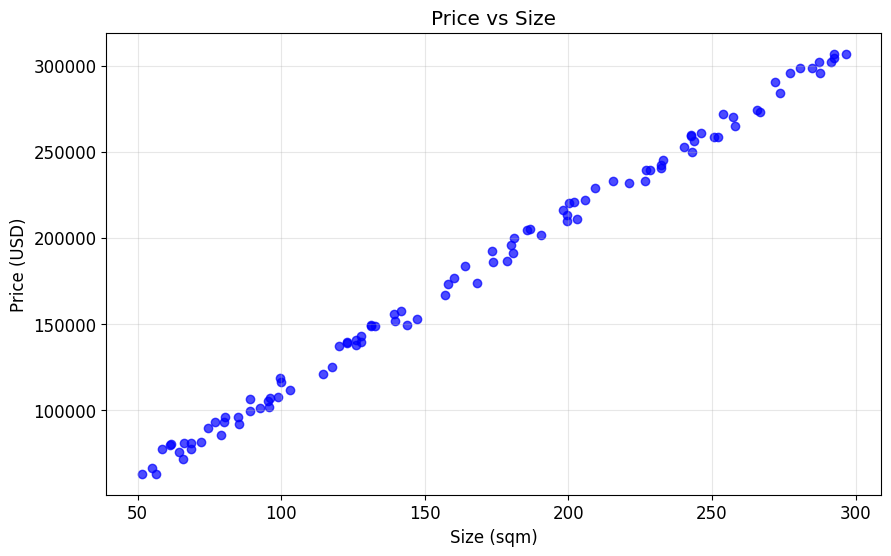

In [44]:
plt.scatter(df['size_sqm'], df['price_uds'], c='blue', alpha=0.7)
plt.xlabel('Size (sqm)')
plt.ylabel('Price (USD)')
plt.title('Price vs Size')
plt.grid(True, alpha=0.3)
plt.show()

In [45]:
# Prepare x_train and y_train
x_train = df['size_sqm'].values
y_train = df['price_uds'].values

m = x_train.shape[0]  # Number of training examples
print("\n✓ Number of training examples (m):", m)
print("\n✓ x_train shape:", x_train.shape)
print("✓ y_train shape:", y_train.shape)


✓ Number of training examples (m): 100

✓ x_train shape: (100,)
✓ y_train shape: (100,)


In [ ]:
def compute_cost(x, y, w, b):
    """
    Computes the cost function for linear regression.

    Args:
        x (ndarray (m,)) : training data features
        y (ndarray (m,)) : target values
        w, b (scalar)    : model parameters

    Returns:
        total_cost (float): cost J(w,b)
    """

    m = x.shape[0]
    cost = 0

    for i in range(m):
        f_wb = w * x[i] + b  # Predicted value
        cost = cost + (f_wb - y[i]) ** 2
    total_cost = 1/(2 * m) * cost

    return total_cost


# Test with w=0, b=0
w_test, b_test = 0, 0
print(f"Initial cost (w=0, b=0): {compute_cost(x_train, y_train, w_test, b_test):.2f}")

# Test with values closer to the solution
w_test, b_test = 1500, 10000
print(f"Cost (w=1500, b=10000): {compute_cost(x_train, y_train, w_test, b_test):.2f}")


Initial cost (w=0, b=0): 19019843814.98
Cost (w=1500, b=10000): 3966679428.82
Cost (w=2000, b=10000): 51311714277184008.00


In [47]:
def compute_gradient(x, y, w, b):
    """
    Computes the gradient of the cost function.

    Args:
        x (ndarray (m,)) : training data features
        y (ndarray (m,)) : target values
        w, b (scalar)    : model parameters

    Returns:
        dj_dw (scalar): gradient w.r.t. w
        dj_db (scalar): gradient w.r.t. b
    """
     
    m = x.shape[0]

    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b  # Predicted value
        dj_dw_i = (f_wb - y[i]) * x[i]  # Partial derivative w.r.t. w
        dj_db_i = f_wb - y[i]  # Partial derivative w.r.t. b
        dj_dw = dj_dw + dj_dw_i
        dj_db = dj_db + dj_db_i

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw , dj_db

# Test
dj_dw, dj_db = compute_gradient(x_train, y_train, 0, 0)
print(f"dj_dw: {dj_dw:,.2f}")
print(f"dj_db: {dj_db:,.2f}")

dj_dw: -35,702,379.04
dj_db: -180,351.28


In [48]:
import math


def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
   """
    Performs gradient descent to fit w,b. Updates w,b by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      x (ndarray (m,))  : Data, m examples 
      y (ndarray (m,))  : target values
      w_in,b_in (scalar): initial values of model parameters  
      alpha (float):     Learning rate
      num_iters (int):   number of iterations to run gradient descent
      cost_function:     function to call to produce cost
      gradient_function: function to call to produce gradient
      
    Returns:
      w (scalar): Updated value of parameter after running gradient descent
      b (scalar): Updated value of parameter after running gradient descent
      J_history (List): History of cost values
      p_history (list): History of parameters [w,b] 
    """
   J_history = []
   p_history = []
   b = b_in
   w = w_in
   
   for i in range(num_iters):
      dj_dw, dj_db = gradient_function(x, y, w, b)

      b = b - alpha * dj_db
      w = w - alpha * dj_dw

      if i<100000:      # prevent resource exhaustion
            J_history.append(cost_function(x, y, w, b))
            p_history.append([w,b])

      if i % math.ceil(num_iters / 10) == 0:
        print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")
   
   return w, b, J_history, p_history

In [52]:
# initialize parameters
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-6
# run gradient descent
w_final, b_final, J_history, p_history = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 1.78e+10  dj_dw: -3.570e+07, dj_db: -1.804e+05   w:  3.570e+01, b: 1.80351e-01
Iteration 1000: Cost 2.19e+07  dj_dw:  1.020e+01, dj_db: -2.042e+03   w:  1.064e+03, b: 7.35909e+00
Iteration 2000: Cost 2.19e+07  dj_dw:  1.020e+01, dj_db: -2.042e+03   w:  1.064e+03, b: 9.40078e+00
Iteration 3000: Cost 2.19e+07  dj_dw:  1.019e+01, dj_db: -2.041e+03   w:  1.064e+03, b: 1.14421e+01
Iteration 4000: Cost 2.19e+07  dj_dw:  1.019e+01, dj_db: -2.041e+03   w:  1.064e+03, b: 1.34832e+01
Iteration 5000: Cost 2.19e+07  dj_dw:  1.019e+01, dj_db: -2.041e+03   w:  1.064e+03, b: 1.55239e+01
Iteration 6000: Cost 2.19e+07  dj_dw:  1.019e+01, dj_db: -2.040e+03   w:  1.064e+03, b: 1.75642e+01
Iteration 7000: Cost 2.19e+07  dj_dw:  1.019e+01, dj_db: -2.040e+03   w:  1.064e+03, b: 1.96042e+01
Iteration 8000: Cost 2.19e+07  dj_dw:  1.019e+01, dj_db: -2.040e+03   w:  1.064e+03, b: 2.16439e+01
Iteration 9000: Cost 2.19e+07  dj_dw:  1.018e+01, dj_db: -2.039e+03   w:  1.064e+03, b: 2.36833e+01


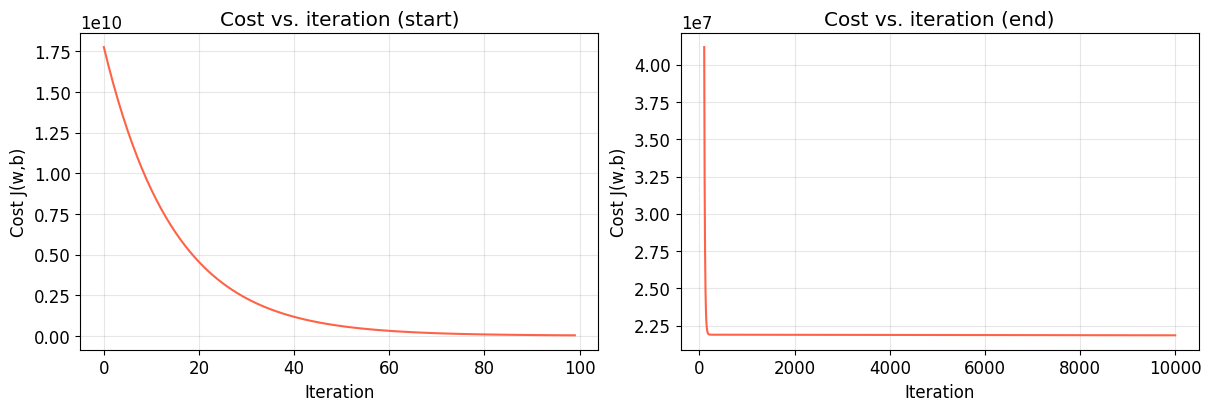

In [53]:
# Two plots: start and end of training (same style as DeepLearning.AI)
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))

ax1.plot(J_history[:100], color='tomato')
ax1.set_title("Cost vs. iteration (start)")
ax1.set_ylabel('Cost J(w,b)')
ax1.set_xlabel('Iteration')
ax1.grid(True, alpha=0.3)

ax2.plot(np.arange(100, len(J_history)), J_history[100:], color='tomato')
ax2.set_title("Cost vs. iteration (end)")
ax2.set_ylabel('Cost J(w,b)')
ax2.set_xlabel('Iteration')
ax2.grid(True, alpha=0.3)

plt.show()

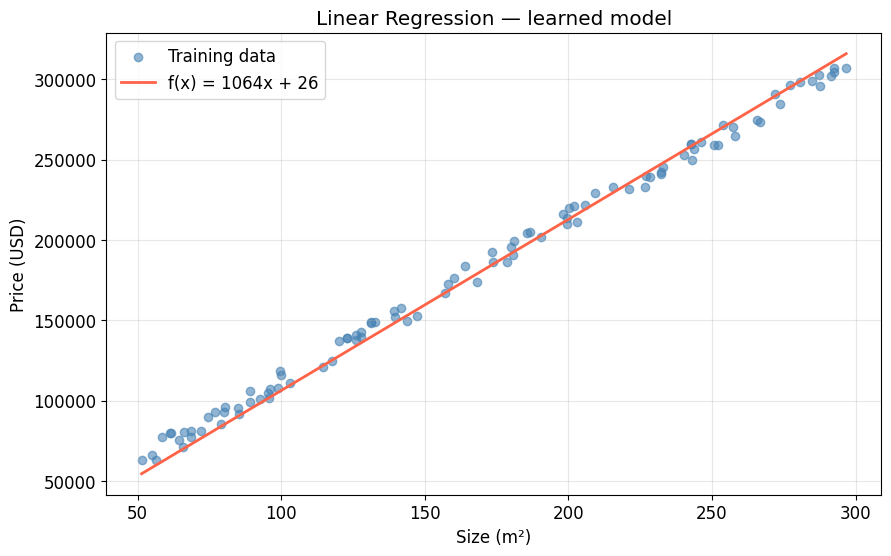

In [50]:
x_line = np.linspace(x_train.min(), x_train.max(), 100)
y_line = w_final * x_line + b_final

plt.scatter(x_train, y_train, color='steelblue', alpha=0.6, label='Training data')
plt.plot(x_line, y_line, color='tomato', linewidth=2, label=f'f(x) = {w_final:.0f}x + {b_final:.0f}')
plt.xlabel('Size (m²)')
plt.ylabel('Price (USD)')
plt.title('Linear Regression — learned model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [51]:
print("Predictions using learned model:")
print("-" * 45)
for size in [80, 120, 150, 200, 250]:
    prediction = w_final * size + b_final
    print(f"  House {size:3d} m²  →  ${prediction:>10,.0f} USD")

Predictions using learned model:
---------------------------------------------
  House  80 m²  →  $    85,155 USD
  House 120 m²  →  $   127,719 USD
  House 150 m²  →  $   159,642 USD
  House 200 m²  →  $   212,848 USD
  House 250 m²  →  $   266,053 USD
